# Bài toán Linear Regression: Dự đoán cân nặng dựa trên chiều cao

Trong bài toán này, chúng ta sẽ áp dụng thuật toán Linear Regression để tìm ra mối quan hệ giữa chiều cao và cân nặng của một người.

Giả sử hàm dự đoán có dạng tuyến tính:
$y \approx f(x) = \hat{y}$
$f(x) = w_1x_1 + w_0$

Trong đó:
* $x_1$ là chiều cao (input).
* $y$ là cân nặng thực tế.
* $\hat{y}$ là cân nặng dự đoán.
* $w_1$ là trọng số (weight) và $w_0$ là độ lệch (bias) cần tìm để sai số giữa $y$ và $\hat{y}$ là nhỏ nhất.

Trước tiên, chúng ta sẽ khởi tạo tập dữ liệu quan sát được gồm 15 người.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dữ liệu chiều cao (cm) - Ma trận X
X = np.array([[147, 150, 153, 158, 160, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T

# Dữ liệu cân nặng (kg) - Ma trận y
y = np.array([[ 49, 50, 51,  54, 56, 58, 59, 60, 72, 63, 64, 66, 67, 68]]).T

Để tìm tập trọng số tối ưu $\mathbf{w} = [w_0, w_1]^T$, bài toán tối ưu hóa hàm mất mát (loss function) bằng cách giải phương trình đạo hàm bằng 0. Nghiệm của bài toán được tính thông qua ma trận giả nghịch đảo (pseudo-inverse) theo công thức:

$$\mathbf{w} = (\mathbf{\bar{X}}^T \mathbf{\bar{X}})^{\dagger} \mathbf{\bar{X}}^T \mathbf{y}$$

Để tính toán ma trận, ta cần xây dựng vector đầu vào mở rộng $\mathbf{\bar{X}}$ bằng cách ghép thêm một cột chứa toàn số `1` vào bên trái ma trận `X`. Điều này giúp gộp hệ số bias $w_0$ vào chung phép nhân ma trận cho gọn nhẹ.

w =  [[-36.88153013]
 [  0.58258348]]


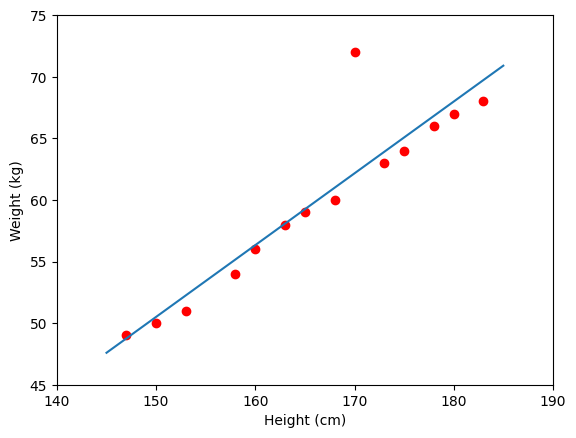

In [4]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)

# Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, y.T, 'ro')     # data
plt.plot(x0, y0)               # the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

Từ đồ thị trên, các điểm dữ liệu thực tế (chấm đỏ) bám khá sát đường dự đoán (đường thẳng xanh). Mô hình hồi quy tuyến tính hoạt động tốt trên tập dữ liệu này.

Bây giờ, ta sẽ dùng bộ trọng số $w_0, w_1$ vừa tìm được để dự đoán thử cân nặng cho hai chiều cao chưa từng xuất hiện trong tập huấn luyện: 155 cm và 160 cm.

In [5]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 53.42 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 56.33 (kg), real number: 56 (kg)


## Kiểm chứng lại bằng thư viện Scikit-learn

Thay vì phải tự nhân ma trận và tính giả nghịch đảo bằng `numpy`, trong thực tế, chúng ta thường sử dụng thư viện `scikit-learn` chuyên dụng cho Machine Learning để mô hình hóa nhanh gọn hơn. Dưới đây là cách dùng thư viện này và so sánh nghiệm với công thức toán học ta vừa làm.
Thay vì phải tự nhân ma trận và tính giả nghịch đảo bằng `numpy`, trong thực tế, chúng ta thường sử dụng thư viện `scikit-learn` chuyên dụng cho Machine Learning để mô hình hóa nhanh gọn hơn. Dưới đây là cách dùng thư viện này và so sánh nghiệm với công thức toán học ta vừa làm.

In [6]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept = False for calculating the bias
regr.fit(Xbar, y)

# Compare two results
print( 'Solution found by scikit-learn  : ', regr.coef_ )
print( 'Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-36.88153013   0.58258348]]
Solution found by (5):  [[-36.88153013   0.58258348]]
